# Cognifyz Data Analysis Internship

# Level 2 - Task 3 : Geographic Analysis

## Objectives

• Explore restaurant locations using latitude and longitude

• Identify cities with highest restaurant concentration

• Visualize restaurant distribution

• Discover geographical patterns

---

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(

    style='whitegrid',

    context='talk'

)

df = pd.read_csv("../Dataset.csv")

df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [19]:
df[['Latitude','Longitude']].describe()

,Latitude,Longitude
count,9551.000000,9551.000000
mean,25.854381,64.126574
std,11.007935,41.467058
min,-41.330428,-157.948486
25%,28.478713,77.081343
50%,28.570469,77.191964
75%,28.642758,77.282006
max,55.976980,174.832089


In [20]:
print(

    "Minimum Latitude :",

    df['Latitude'].min()

)

print(

    "Maximum Latitude :",

    df['Latitude'].max()

)

print(

    "Minimum Longitude :",

    df['Longitude'].min()

)

print(

    "Maximum Longitude :",

    df['Longitude'].max()

)

Minimum Latitude : -41.330428
Maximum Latitude : 55.97698
Minimum Longitude : -157.948486
Maximum Longitude : 174.8320893


## Restaurant Distribution by City

In [21]:
cities = (

    df['City']

    .value_counts()

    .head(10)

)

cities

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Ahmedabad         21
Amritsar          21
Bhubaneshwar      21
Guwahati          21
Lucknow           21
Name: count, dtype: int64

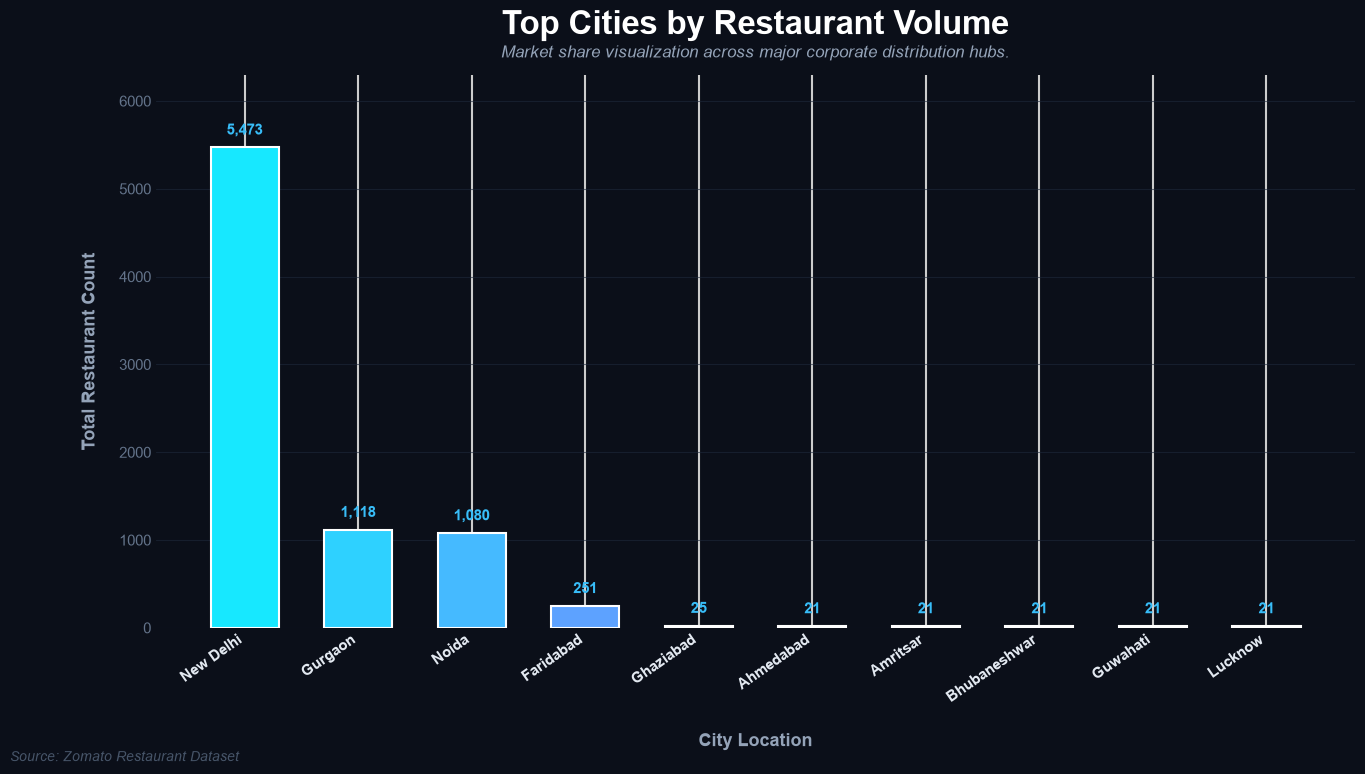

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(14, 8), facecolor="#0B0F19")
ax.set_facecolor("#0B0F19")

colors = sns.color_palette("cool", len(cities))

bars = ax.bar(
    cities.index,
    cities.values,
    color=colors,
    width=0.6,
    zorder=3
)

max_val = cities.values.max() if len(cities) > 0 else 1000
for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"{int(height):,}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="#38BDF8",
        zorder=4
    )

ax.text(
    0.5, 1.09, "Top Cities by Restaurant Volume",
    transform=ax.transAxes, ha="center", va="center",
    fontsize=24, fontweight="bold", color="#FFFFFF"
)
ax.text(
    0.5, 1.04, "Market share visualization across major corporate distribution hubs.",
    transform=ax.transAxes, ha="center", va="center",
    fontsize=12, color="#94A3B8", style="italic"
)

ax.set_xlabel("City Location", fontsize=13, fontweight="bold", labelpad=20, color="#94A3B8")
ax.set_ylabel("Total Restaurant Count", fontsize=13, fontweight="bold", labelpad=15, color="#94A3B8")

plt.xticks(rotation=35, ha="right", fontsize=11, fontweight="bold", color="#E2E8F0")
plt.yticks(fontsize=11, color="#64748B")

ax.set_ylim(0, max_val * 1.15)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(axis="y", linestyle="-", linewidth=0.8, color="#1E293B", alpha=0.6, zorder=0)
ax.tick_params(axis='both', which='both', length=0)

plt.text(
    0.02, 0.02, "Source: Zomato Restaurant Dataset", 
    transform=fig.transFigure, fontsize=10, style="italic", color="#475569"
)

plt.tight_layout()
plt.show()

# Geographic Scatter Plot

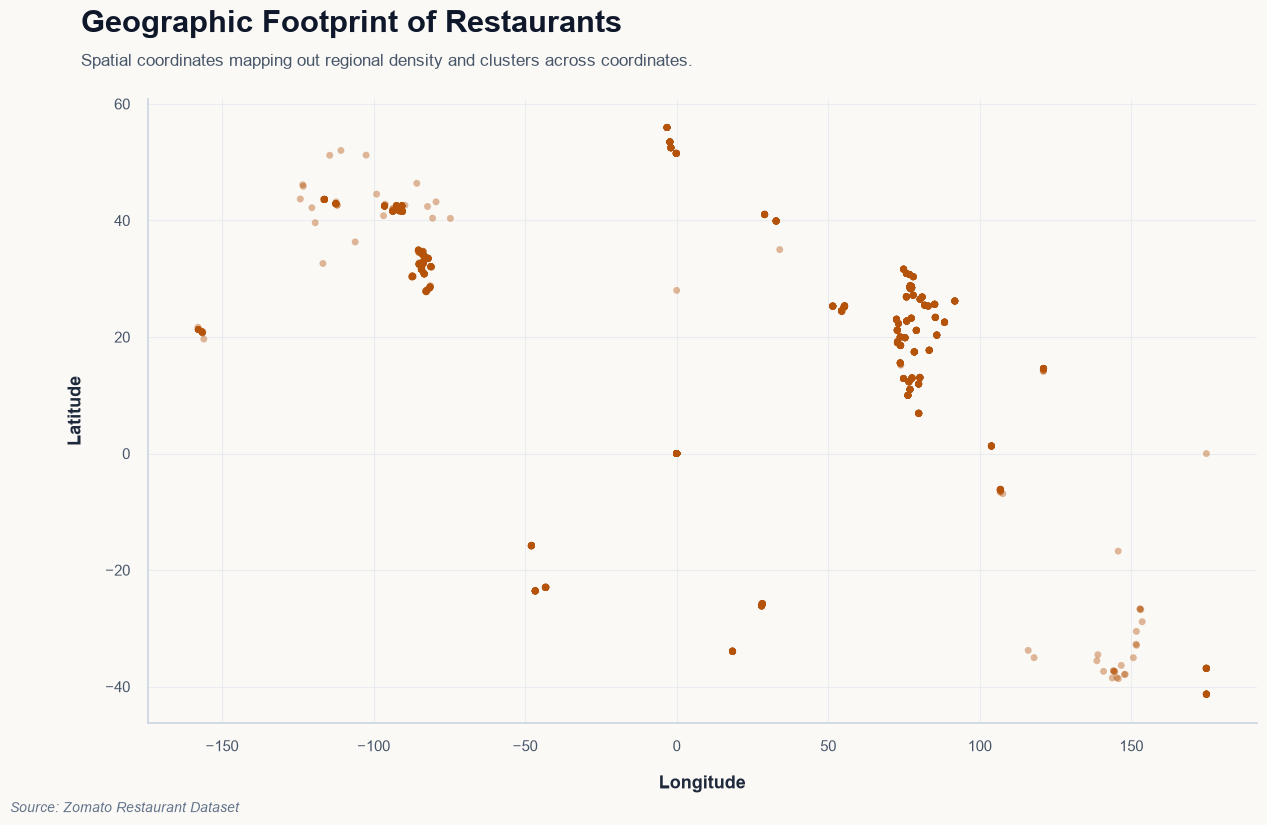

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(13, 8.5), facecolor="#FAF9F6")
ax.set_facecolor("#FAF9F6")

sns.scatterplot(
    data=df,
    x='Longitude',
    y='Latitude',
    alpha=0.4,
    s=25,
    color='#B45309',
    edgecolor='none',
    zorder=3
)

ax.text(
    -0.06, 1.12, "Geographic Footprint of Restaurants",
    transform=ax.transAxes, ha="left", va="center",
    fontsize=22, fontweight="bold", color="#0F172A"
)
ax.text(
    -0.06, 1.06, "Spatial coordinates mapping out regional density and clusters across coordinates.",
    transform=ax.transAxes, ha="left", va="center",
    fontsize=12, color="#475569"
)

ax.set_xlabel("Longitude", fontsize=13, fontweight="bold", labelpad=15, color="#1E293B")
ax.set_ylabel("Latitude", fontsize=13, fontweight="bold", labelpad=15, color="#1E293B")

plt.xticks(fontsize=11, color="#475569")
plt.yticks(fontsize=11, color="#475569")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["left"].set_color("#CBD5E1")
ax.spines["bottom"].set_linewidth(1.2)
ax.spines["bottom"].set_color("#CBD5E1")

ax.grid(axis="both", linestyle="-", linewidth=0.8, color="#E2E8F0", alpha=0.7, zorder=0)
ax.tick_params(axis='both', which='both', color="#CBD5E1")

plt.text(
    0.02, 0.02, "Source: Zomato Restaurant Dataset", 
    transform=fig.transFigure, fontsize=10, style="italic", color="#64748B"
)

plt.tight_layout()
plt.show()

In [32]:
import folium

m = folium.Map(
    location=[28.61,77.20],
    zoom_start=5
)

for _, row in df.head(500).iterrows():

    folium.CircleMarker(

        location=[
            row['Latitude'],
            row['Longitude']
        ],

        radius=3,

        color='red',

        fill=True,

        fill_opacity=0.7

    ).add_to(m)

m

# Key Insights

• Restaurants are heavily concentrated in metropolitan areas.

• New Delhi dominates restaurant density.

• Latitude and longitude reveal clustering patterns.

• Geographic analysis helps identify food hubs.

# Conclusion

Geographic analysis highlights the uneven distribution of restaurants.

Most establishments are concentrated around major urban centers, indicating higher demand and population density in metropolitan regions.

Spatial visualization provides valuable insights into restaurant expansion opportunities.